In [1]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.model_selection import train_test_split
import torch
import gbtoolbox.bounds as bounds
import gbtoolbox.misc as mt
import gbtoolbox.dft as dft
import numpy as np
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F
import cupy as cp

In [2]:
import numba
from numba import jit
from numba.experimental import jitclass
@jit(nopython=True)
def rmse(y1, y2):
    return np.sqrt(((y1-y2)*np.conj(y1-y2)).mean())

In [3]:
digits = datasets.load_digits()
print(digits.data.shape)
print(digits.images.shape)
print(digits.target.shape)

(1797, 64)
(1797, 8, 8)
(1797,)


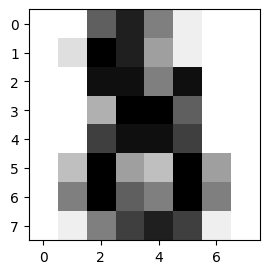

In [4]:
plt.figure(1, figsize=(3, 3))
plt.imshow(digits.images[-1], cmap=plt.cm.gray_r)
plt.show()

In [5]:
num_features = 6
pca = PCA(num_features)
small_data = pca.fit_transform(digits.data)
print(pca.explained_variance_)
print(pca.components_.shape)
print(small_data.shape)

[179.0069301  163.71774688 141.78843909 101.1003752   69.51316556
  59.10852458]
(6, 64)
(1797, 6)


In [6]:
amax = np.max(np.abs(small_data),axis=0)
print(amax)
s_data=small_data/amax

[31.70012535 30.09220573 32.70885494 35.48735609 27.60095007 21.06814267]


In [7]:
targets = digits.target
targets[targets!=5]=0
targets[targets==5]=1

In [8]:
X_train, X_test, y_train, y_test = train_test_split(s_data, targets, test_size=0.3, random_state=42)

In [9]:
batch_size = 64
testset = TensorDataset(torch.Tensor(X_test),torch.Tensor(y_test)) # create your datset
trainset = TensorDataset(torch.Tensor(X_train),torch.Tensor(y_train)) # create your datset
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

In [10]:
MM=8000

In [11]:
class ShallowClassifier(nn.Module):
    def __init__(self):
        super(ShallowClassifier,self).__init__()
        self.fc1 = nn.Linear(num_features,MM)
        self.fc2 = nn.Linear(MM,1)     
        #self.fc1.weight = torch.nn.Parameter(torch.Tensor(wh.T))
        #self.fc1.bias = torch.nn.Parameter(torch.Tensor(tv*zv))      
        #self.fc2.bias = torch.nn.Parameter(torch.Tensor(np.array([np.mean(y)])))
        #self.fc2.weight = torch.nn.Parameter(torch.Tensor((sne)*(sv).reshape(-1,1).T/MM))
      
        
    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [12]:
model = ShallowClassifier()
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.FloatTensor ([9.0]))
optimizer = torch.optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, momentum=0.9)

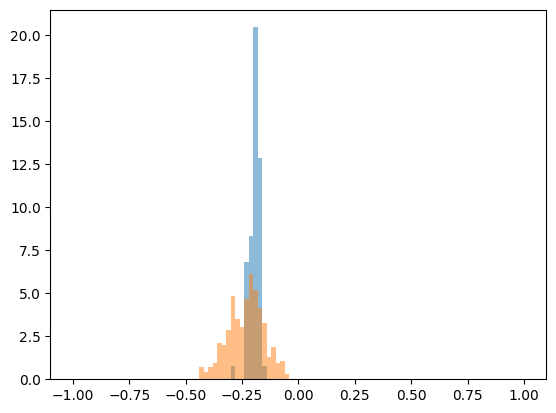

In [13]:
check_output = model(torch.Tensor(X_test))
plt.hist(check_output.detach().cpu().numpy()[y_test>.5],alpha = 0.5,bins=100,density=True,range=(-1,1))
plt.hist(check_output.detach().cpu().numpy()[y_test<.5],alpha = 0.5,bins=100,density=True,range=(-1,1))
plt.show()

In [14]:
loss = criterion(check_output, torch.Tensor(y_test).reshape((-1, 1)))
print(loss)

tensor(1.3879, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


In [15]:
for epoch in range(90):  # loop over the dataset multiple times

    running_loss = 0.0
    counter = 0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels.reshape((-1, 1)))
        loss.backward()
        optimizer.step()
        # print statistics
        running_loss += loss.item()
        counter += 1
        #if i % 200 == 199:    # print every 2000 mini-batches
    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / counter:.3f}')
    running_loss = 0.0

print('Finished Training')

[1,    20] loss: 0.770
[2,    20] loss: 0.286
[3,    20] loss: 0.210
[4,    20] loss: 0.186
[5,    20] loss: 0.173
[6,    20] loss: 0.165
[7,    20] loss: 0.155
[8,    20] loss: 0.152
[9,    20] loss: 0.150
[10,    20] loss: 0.155
[11,    20] loss: 0.141
[12,    20] loss: 0.138
[13,    20] loss: 0.139
[14,    20] loss: 0.138
[15,    20] loss: 0.130
[16,    20] loss: 0.129
[17,    20] loss: 0.127
[18,    20] loss: 0.125
[19,    20] loss: 0.125
[20,    20] loss: 0.122
[21,    20] loss: 0.119
[22,    20] loss: 0.119
[23,    20] loss: 0.118
[24,    20] loss: 0.117
[25,    20] loss: 0.119
[26,    20] loss: 0.116
[27,    20] loss: 0.114
[28,    20] loss: 0.114
[29,    20] loss: 0.117
[30,    20] loss: 0.110
[31,    20] loss: 0.110
[32,    20] loss: 0.114
[33,    20] loss: 0.107
[34,    20] loss: 0.110
[35,    20] loss: 0.109
[36,    20] loss: 0.106
[37,    20] loss: 0.107
[38,    20] loss: 0.106
[39,    20] loss: 0.105
[40,    20] loss: 0.104
[41,    20] loss: 0.104
[42,    20] loss: 0.102
[

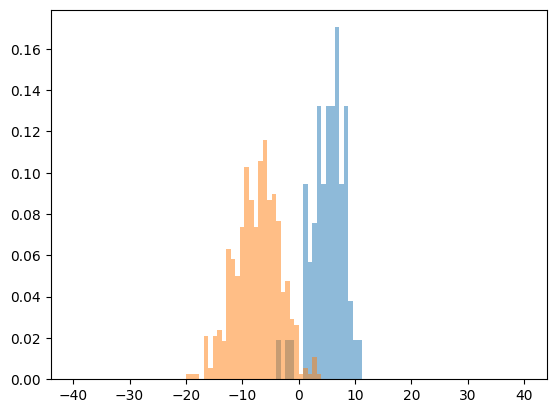

In [16]:
check_output = model(torch.Tensor(X_test))
plt.hist(check_output.detach().cpu().numpy()[y_test>.5],alpha = 0.5,bins=100,density=True,range=(-40,40))
plt.hist(check_output.detach().cpu().numpy()[y_test<.5],alpha = 0.5,bins=100,density=True,range=(-40,40))
plt.show()

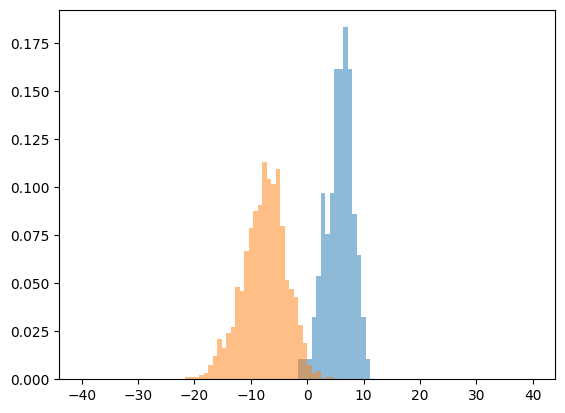

In [17]:
check_output = model(torch.Tensor(X_train))
plt.hist(check_output.detach().cpu().numpy()[y_train>.5],alpha = 0.5,bins=100,density=True,range=(-40,40))
plt.hist(check_output.detach().cpu().numpy()[y_train<.5],alpha = 0.5,bins=100,density=True,range=(-40,40))
plt.show()

In [18]:
y_mod_test=y_test*20-10
y_mod_train=y_train*20-10
print(y_mod_test[:40])
print(y_test[:40])

[-10 -10 -10 -10 -10 -10  10 -10  10 -10 -10 -10 -10 -10 -10 -10 -10 -10
 -10 -10 -10 -10 -10 -10  10 -10 -10  10 -10 -10 -10 -10 -10 -10 -10 -10
 -10 -10 -10 -10]
[0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0]


In [19]:
print(X_train)
tmin = np.min(X_train,axis=0)
tmax = np.max(X_train,axis=0)
print(tmax,tmin)
fmax=np.ones(6)
fmin=np.ones(6)
fmax[0]=np.max(np.fft.fftshift(np.fft.fftfreq(100,(tmin[0]-tmax[0])/100.)))
fmax[1]=np.max(np.fft.fftshift(np.fft.fftfreq(100,(tmin[1]-tmax[1])/100.)))
fmax[2]=np.max(np.fft.fftshift(np.fft.fftfreq(100,(tmin[2]-tmax[2])/100.)))
fmax[3]=np.max(np.fft.fftshift(np.fft.fftfreq(100,(tmin[3]-tmax[3])/100.)))
fmax[4]=np.max(np.fft.fftshift(np.fft.fftfreq(100,(tmin[4]-tmax[4])/100.)))
fmax[5]=np.max(np.fft.fftshift(np.fft.fftfreq(100,(tmin[5]-tmax[5])/100.)))
fmin[0]=np.min(np.fft.fftshift(np.fft.fftfreq(100,(tmin[0]-tmax[0])/100.)))
fmin[1]=np.min(np.fft.fftshift(np.fft.fftfreq(100,(tmin[1]-tmax[1])/100.)))
fmin[2]=np.min(np.fft.fftshift(np.fft.fftfreq(100,(tmin[2]-tmax[2])/100.)))
fmin[3]=np.min(np.fft.fftshift(np.fft.fftfreq(100,(tmin[3]-tmax[3])/100.)))
fmin[4]=np.min(np.fft.fftshift(np.fft.fftfreq(100,(tmin[4]-tmax[4])/100.)))
fmin[5]=np.min(np.fft.fftshift(np.fft.fftfreq(100,(tmin[5]-tmax[5])/100.)))
print(fmax,fmin)

[[-0.186918    0.2907026  -0.14840667 -0.09396878 -0.17133549 -0.06041457]
 [ 0.04218546 -0.65210757 -0.49401177  0.17319482 -0.29898226  0.28142673]
 [ 0.26067169 -0.17628656  0.74154538 -0.31831111  0.22083918  0.08127267]
 ...
 [-0.37203609 -0.4092026  -0.02649415  0.05929859 -0.65851314  0.10383664]
 [ 0.17374211 -0.31716084 -0.47627841  0.14565918 -0.09188445  0.17660647]
 [ 0.45502481 -0.51959735  0.41248492 -0.09871063 -0.2150616  -0.38487816]]
[1.         0.96988261 1.         1.         1.         0.96340668] [-0.98327385 -0.91367334 -0.89583526 -0.85828665 -0.78341578 -0.86183423]
[25.21084019 26.54553479 26.37359955 26.90650548 28.03608704 27.39364417] [-24.70662339 -26.01462409 -25.84612756 -26.36837538 -27.4753653
 -26.84577129]


In [20]:
grid_info = np.array([[fmin[j]/2, fmax[j]/2,24] for j in np.arange(6)])
ycomp = (1/X_train.shape[0])/(np.sqrt(2*np.pi)**2)
calcdft = dft.nu_dft_cupy(X_train, y_mod_train,[0])
yf, f, yfu, yfuc = (calcdft.process_grid(grid_info, 0.0, ycomp, 0))

 initializing with  13.0.0
 Diagnostics 
[[ -30.45  -30.03  -29.6  ...  -12.44  -12.01  -11.58]
 [ -77.8   -79.8   -81.8  ...  -82.06  -84.06  -86.06]
 [  65.56   65.     64.44 ...   42.03   41.47   40.88]
 ...
 [-107.56 -108.3  -109.06 ...  -69.3   -70.06  -70.8 ]
 [ -32.06  -33.34  -34.6  ...  -41.7   -42.97  -44.22]
 [ -32.8   -30.06  -27.34 ...   18.31   21.05   23.78]]


In [21]:
print(yf.shape,f.shape,yfu.shape,yfuc.shape)
yf = cp.asnumpy(yf)



(191102976,) (191102976, 6) (30,) (30,)


7076007.0


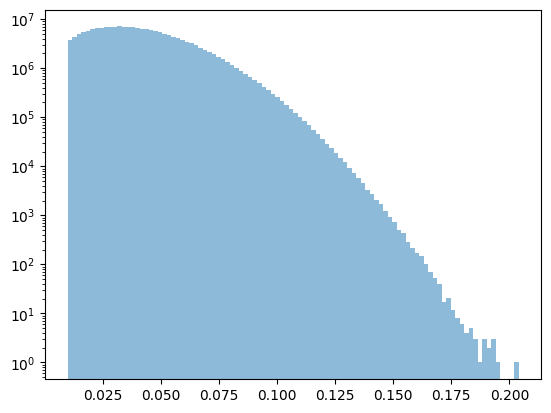

In [22]:
entries, bin_edges, patches = plt.hist(np.abs(yf),alpha = 0.5,bins=100, density=False,range=[0.01,.2*np.max(np.abs(yf))])
print(np.max(entries))
plt.yscale('log')


In [23]:
peak=np.argmax(entries, axis=None)
print(peak)
peakcorr = 1
sigma=(bin_edges[peak]+peakcorr*bin_edges[peak+1])/(1+peakcorr)
print(sigma)

11
0.03229677677154541


6953629.0


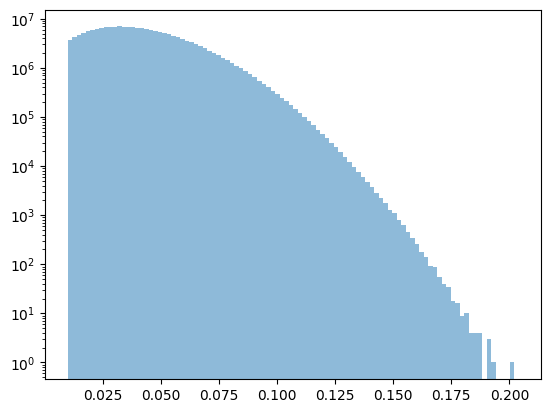

In [24]:
bentries, bbin_edges, bpatches = plt.hist(np.abs(np.random.normal(0, sigma, yf.shape[0])+1.j*np.random.normal(0, sigma, yf.shape[0])),alpha = 0.5,bins=100, density=False,range=[0.01,.2*np.max(np.abs(yf))])
print(np.max(bentries))
plt.yscale('log')


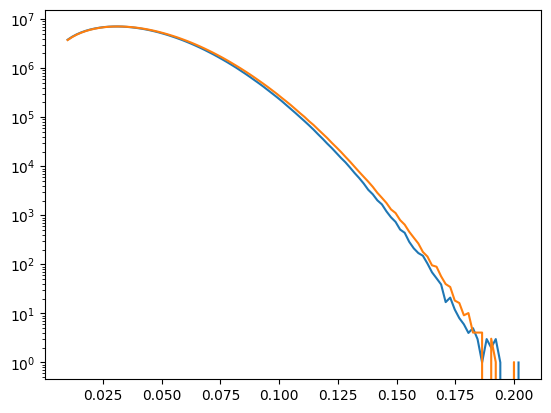

In [25]:
plt.plot(bin_edges[:100],entries)
plt.plot(bbin_edges[:100],bentries*np.max(entries)/np.max(bentries))
plt.yscale('log')


In [26]:
nf=cp.asnumpy(f)
nyf=cp.asnumpy(yf)
# we were sampling on a grid
# even the ones we set to 0, are not 'not sampled' but are rather set to 0
# the proper normalization is giong to be max()-min()/number along dimension
ycomp = np.prod([(np.pi*(fmax[i]-fmin[i]))/23 for i in range(6)])
with cp.cuda.Device(0):
    ty = calcdft.process_inv(cp.asarray(nyf[np.abs(nyf)>.0].reshape(-1,1)/ycomp),cp.asarray(nf[np.abs(nyf)>.0,:]),0,2)

 Diagnostics 
(1257, 6)
(6, 191102976)
[[-77.56 -77.56 -77.56 -77.56]
 [-81.7  -81.7  -81.7  -81.7 ]
 [-81.2  -81.2  -81.2  -81.2 ]
 [-82.8  -82.8  -82.8  -82.8 ]
 [-86.25 -86.25 -86.25 -86.25]
 [-84.3  -77.2  -70.1  -63.  ]]
[[-0.1869   0.2908  -0.1484  -0.094   -0.1714  -0.06042]
 [ 0.04218 -0.6523  -0.494    0.1732  -0.299    0.2815 ]
 [ 0.2607  -0.1763   0.7417  -0.3184   0.2208   0.0813 ]
 [ 0.8467  -0.0409  -0.313   -0.0992   0.2517  -0.0777 ]]
[[72.7  72.7  72.7  72.7 ]
 [76.44 76.44 76.44 76.44]
 [76.   76.   76.   76.  ]
 [77.56 77.56 77.56 77.56]
 [80.75 80.75 80.75 80.75]
 [57.62 64.75 71.8  78.94]]
[[-0.1456   -0.6147    0.002699  0.2451   -0.441     0.191   ]
 [-0.372    -0.4092   -0.02649   0.0593   -0.6587    0.1038  ]
 [ 0.1737   -0.3171   -0.4763    0.1456   -0.09186   0.1766  ]
 [ 0.455    -0.5195    0.4126   -0.0987   -0.2151   -0.3848  ]]
 Diagnostics 
[[ 30.45  30.03  29.6  ... -27.69 -28.11 -28.55]
 [ 77.8   79.8   81.8  ... -76.8  -74.8  -72.8 ]]
 Diagnostics 
[[

In [27]:
print(f[:4,:])
print(f[-4:,:])
print(np.max(nf,axis=0))
print(np.min(nf,axis=0))

[[-12.35  -13.01  -12.92  -13.19  -13.734 -13.42 ]
 [-12.35  -13.01  -12.92  -13.19  -13.734 -12.29 ]
 [-12.35  -13.01  -12.92  -13.19  -13.734 -11.164]
 [-12.35  -13.01  -12.92  -13.19  -13.734 -10.03 ]]
[[11.57  12.17  12.1   12.35  12.86   9.17 ]
 [11.57  12.17  12.1   12.35  12.86  10.305]
 [11.57  12.17  12.1   12.35  12.86  11.44 ]
 [11.57  12.17  12.1   12.35  12.86  12.56 ]]
[11.57 12.17 12.1  12.35 12.86 12.56]
[-12.35  -13.01  -12.92  -13.19  -13.734 -13.42 ]


In [28]:
with cp.cuda.Device(0):
    print(ty[:20,:]*2*np.pi)
print(np.sqrt(2*np.pi))
print(ty.dtype)
print(y_mod_train[:20])
print(ycomp)

[[-10.65465979-8.07821571e-03j]
 [-10.64277444+2.70290390e-03j]
 [-10.65311607-1.71446227e-05j]
 [-10.64809768-1.62160995e-03j]
 [-10.64283548+5.62593967e-03j]
 [-10.64642625-3.00620220e-03j]
 [-10.64844634+1.07600688e-03j]
 [-10.63902599+2.12832044e-02j]
 [ 10.65021701-3.98106640e-04j]
 [-10.64989943-1.28373439e-04j]
 [-10.64916278-9.04726783e-04j]
 [-10.65227118+1.36430643e-04j]
 [-10.64964177-3.88843625e-05j]
 [-10.64813026+1.69755405e-03j]
 [-10.65664618+8.49831787e-04j]
 [-10.65920106+2.41319657e-03j]
 [-10.65007545+2.37380420e-03j]
 [-10.64889463+2.60972653e-03j]
 [-10.65151992+1.24776388e-03j]
 [-10.61279178+6.61276898e-03j]]
2.5066282746310002
complex128
[-10 -10 -10 -10 -10 -10 -10 -10  10 -10 -10 -10 -10 -10 -10 -10 -10 -10
 -10 -10]
142723.69298226835


In [29]:
# we have some tests
# basically the value at 0 for the fourier space should be the same as the integral of the function,
# not the measured values, for the real space function
# maybe best is just to rescale
with cp.cuda.Device(0):
    print(ty[:20,:]/np.median(cp.asnumpy(ty))*np.median(y_mod_train))
    print(" the rms is ",rmse(cp.asnumpy(ty)/np.median(cp.asnumpy(ty))*np.median(y_mod_train),y_mod_train))
    print(" the real rms is ",rmse((cp.asnumpy(ty)/np.median(cp.asnumpy(ty))*np.median(y_mod_train)).real,y_mod_train))
    print(" the imag rms is ",rmse((cp.asnumpy(ty)/np.median(cp.asnumpy(ty))*np.median(y_mod_train)).imag,y_mod_train*0))
    print(" the imag rms is (no corr) ",rmse(cp.asnumpy(ty).imag,y_mod_train*0))

[[-10.0027015 -6.04083325e-03j]
 [ -9.99154185+4.07886751e-03j]
 [-10.00125108+1.52675671e-03j]
 [ -9.99653999+1.97419445e-05j]
 [ -9.99159874+6.82305133e-03j]
 [ -9.99497104-1.28036907e-03j]
 [ -9.99686693+2.55234188e-03j]
 [ -9.98802009+2.15216951e-02j]
 [  9.99852935-1.91617885e-03j]
 [ -9.99823128+1.42186814e-03j]
 [ -9.99753981+6.92913226e-04j]
 [-10.00045787+1.67081233e-03j]
 [ -9.99798937+1.50584405e-03j]
 [ -9.9965701 +3.13581075e-03j]
 [-10.00456505+2.34119402e-03j]
 [-10.00696337+3.80926640e-03j]
 [ -9.99839616+3.77096283e-03j]
 [ -9.99728756+3.99227804e-03j]
 [ -9.99975241+2.71403420e-03j]
 [ -9.96339327+7.74514536e-03j]]
 the rms is  (8.188662040322992+0j)
 the real rms is  8.188651951447147
 the imag rms is  0.01285413298458757
 the imag rms is (no corr)  0.0021634315292556943


In [30]:
mempool = cp.get_default_memory_pool()
print(mempool.used_bytes())
print(mempool.total_bytes())
try:
    del calcdft
except:
    print(" nothing to delete ")
    
try:
    del yf
except:
    print(" nothing to delete ")

try:
    del f 
except:
    print(" nothing to delete ")
    
try:
    del yfu
except:
    print(" nothing to delete ")
    
try:
    del yfuc
except:
    print(" nothing to delete ")
mempool.free_all_blocks()
print(mempool.used_bytes())
print(mempool.total_bytes())

2293282816
16053333504
20480
643584


In [31]:
import time

In [32]:
grid_info = np.array([[fmin[j]/2, fmax[j]/2,24] for j in np.arange(6)])
ycomp = (1/X_train.shape[0])/(np.sqrt(2*np.pi)**1)
start = time.time()
calcdft = dft.nu_dft_cupy(X_train, y_mod_train,[0])
print(X_train.shape,y_train.shape)
yf, f, yfu, yfuc = (calcdft.process_grid(grid_info, 1*sigma, ycomp, 0))
print(mempool.used_bytes())
print(mempool.total_bytes())

 initializing with  13.0.0
(1257, 6) (1257,)
 Diagnostics 
[[ -30.45  -30.03  -29.6  ...  -12.44  -12.01  -11.58]
 [ -77.8   -79.8   -81.8  ...  -82.06  -84.06  -86.06]
 [  65.56   65.     64.44 ...   42.03   41.47   40.88]
 ...
 [-107.56 -108.3  -109.06 ...  -69.3   -70.06  -70.8 ]
 [ -32.06  -33.34  -34.6  ...  -41.7   -42.97  -44.22]
 [ -32.8   -30.06  -27.34 ...   18.31   21.05   23.78]]
3519953920
22382569472


[ 9.671536  12.227396  14.677239  ...  8.312903   2.8585346 10.519384 ]
744052030.0
3519953920
22382569472


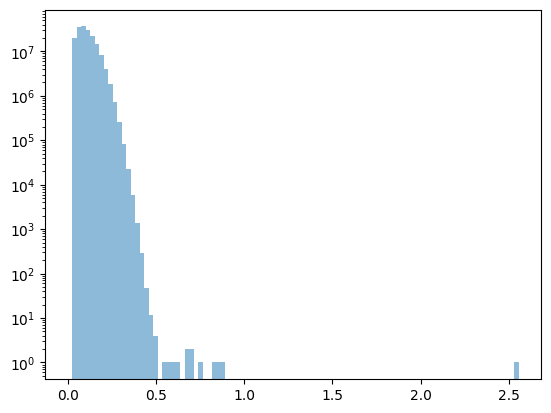

In [33]:
cp.heaviside(cp.abs(yf)-0.032,0.5)*yf
_, _, _= plt.hist(cp.asnumpy(cp.abs(cp.heaviside(cp.abs(yf)-0.032,0.5)*yf)),alpha = 0.5,bins=100, density=False,range=[0,np.max(np.abs(cp.asnumpy(yf)))])
print(cp.asnumpy(cp.heaviside(cp.abs(yf)-0.032,0.5)*cp.abs(yf)*cp.sum(cp.abs(f),axis=1)))
print(cp.asnumpy(cp.heaviside(cp.abs(yf)-0.032,0.5)*cp.abs(yf)*cp.sum(cp.abs(f),axis=1)).sum())
print(mempool.used_bytes())
print(mempool.total_bytes())
plt.yscale('log')


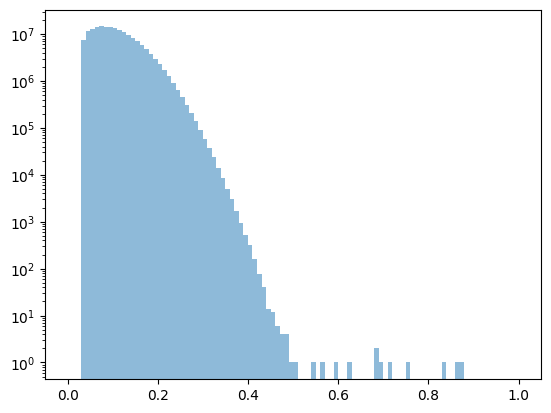

In [34]:
cp.heaviside(cp.abs(yf)-0.032,0.5)*yf
_, _, _= plt.hist(cp.asnumpy(cp.abs(cp.heaviside(cp.abs(yf)-0.032,0.5)*yf)),alpha = 0.5,bins=100, density=False,range=[0,1])
plt.yscale('log')

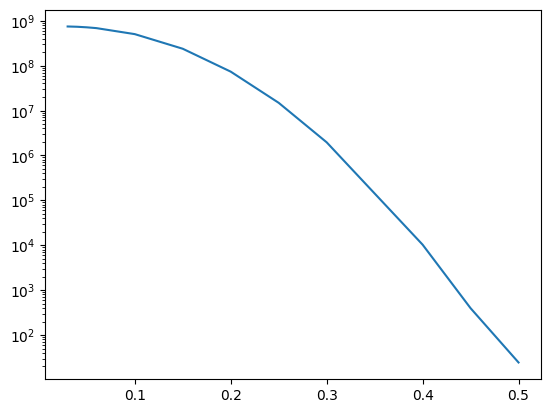

In [35]:
plt.plot([0.03,0.04,0.05,0.06,0.1,0.15,0.2,0.25,0.3,0.4,0.45,0.5],[cp.asnumpy(cp.heaviside(cp.abs(yf)-t,0.5)*cp.abs(yf)*cp.sum(cp.abs(f),axis=1)).sum() for t in [0.03,0.04,0.05,0.06,0.1,0.15,0.2,0.25,0.3,0.4,0.45,0.5]])
plt.yscale('log')


In [36]:
print(yf)
print(yf.shape)
print(cp.abs(yf)>.06)
print(f.shape)
print(f[cp.abs(yf)>.06,:].shape)
print(X_train.shape)
print(y_train.shape)

[ 0.09819441+0.07408728j -0.15766543-0.00582111j  0.16619608+0.09648554j
 ... -0.1001468 -0.05945934j -0.00541508+0.03905444j
  0.06877785+0.12523457j]
(175995316,)
[ True  True  True ...  True False  True]
(175995316, 6)
(143815843, 6)
(1257, 6)
(1257,)


In [37]:
print(f[cp.abs(yf)>.06,:][:4,:6])
nf=cp.asnumpy(f)
nyf=cp.asnumpy(yf)

[[-12.35  -13.01  -12.92  -13.19  -13.734 -13.42 ]
 [-12.35  -13.01  -12.92  -13.19  -13.734 -12.29 ]
 [-12.35  -13.01  -12.92  -13.19  -13.734 -11.164]
 [-12.35  -13.01  -12.92  -13.19  -13.734 -10.03 ]]


In [38]:
ycomp = (1/nf[np.abs(nyf)>.06,:].shape[0])/(np.sqrt(2*np.pi)**1)
ty = calcdft.process_inv(cp.asarray(nyf[np.abs(nyf)>.06].reshape(-1,1)*ycomp),cp.asarray(nf[np.abs(nyf)>.06,:]),0,2)

 Diagnostics 
(1257, 6)
(6, 143815840)
[[-77.56 -77.56 -77.56 -77.56]
 [-81.7  -81.7  -81.7  -81.7 ]
 [-81.2  -81.2  -81.2  -81.2 ]
 [-82.8  -82.8  -82.8  -82.8 ]
 [-86.25 -86.25 -86.25 -86.25]
 [-84.3  -77.2  -70.1  -63.  ]]
[[-0.1869   0.2908  -0.1484  -0.094   -0.1714  -0.06042]
 [ 0.04218 -0.6523  -0.494    0.1732  -0.299    0.2815 ]
 [ 0.2607  -0.1763   0.7417  -0.3184   0.2208   0.0813 ]
 [ 0.8467  -0.0409  -0.313   -0.0992   0.2517  -0.0777 ]]
[[72.7  72.7  72.7  72.7 ]
 [76.44 76.44 76.44 76.44]
 [76.   76.   76.   76.  ]
 [77.56 77.56 77.56 77.56]
 [80.75 80.75 80.75 80.75]
 [43.44 57.62 64.75 78.94]]
[[-0.1456   -0.6147    0.002699  0.2451   -0.441     0.191   ]
 [-0.372    -0.4092   -0.02649   0.0593   -0.6587    0.1038  ]
 [ 0.1737   -0.3171   -0.4763    0.1456   -0.09186   0.1766  ]
 [ 0.455    -0.5195    0.4126   -0.0987   -0.2151   -0.3848  ]]
 Diagnostics 
[[ 30.45  30.03  29.6  ... -27.25 -27.69 -28.55]
 [ 77.8   79.8   81.8  ... -78.8  -76.8  -72.8 ]]
 Diagnostics 
[[

In [39]:
print(ty)
print(ty.dtype)

[[-0.0016266 -1.57540569e-06j]
 [-0.00162457+1.76997958e-06j]
 [-0.00162603+1.25459565e-07j]
 ...
 [-0.00162689+5.25484609e-07j]
 [-0.00162719-5.68247174e-08j]
 [ 0.        +0.00000000e+00j]]
complex128


In [40]:
print(f.shape)
print(yf.shape)
print(f)
print(yf)
print(yf.dtype)
print(nyf.dtype)

(175995316, 6)
(175995316,)
[[-12.35  -13.01  -12.92  -13.19  -13.734 -13.42 ]
 [-12.35  -13.01  -12.92  -13.19  -13.734 -12.29 ]
 [-12.35  -13.01  -12.92  -13.19  -13.734 -11.164]
 ...
 [ 11.57   12.17   12.1    12.35   12.86   10.305]
 [ 11.57   12.17   12.1    12.35   12.86   11.44 ]
 [ 11.57   12.17   12.1    12.35   12.86   12.56 ]]
[ 0.09819441+0.07408728j -0.15766543-0.00582111j  0.16619608+0.09648554j
 ... -0.1001468 -0.05945934j -0.00541508+0.03905444j
  0.06877785+0.12523457j]
complex64
complex64


In [41]:
print(mempool.total_bytes())
mempool.free_all_blocks()

24108359680


In [42]:
nf=cp.asnumpy(f)
nyf=cp.asnumpy(yf)

In [43]:
for t in [0.03,0.04,0.05,0.06,0.1,0.15,0.2,0.25,0.3,0.4,0.45,0.5]:
    print(" for threshold ",t," the size is ",nf[np.abs(nyf)>t,:].shape[0])


 for threshold  0.03  the size is  175995316
 for threshold  0.04  the size is  168417972
 for threshold  0.05  the size is  156865047
 for threshold  0.06  the size is  143815840
 for threshold  0.1  the size is  86751200
 for threshold  0.15  the size is  32325305
 for threshold  0.2  the size is  8103803
 for threshold  0.25  the size is  1368132
 for threshold  0.3  the size is  154443
 for threshold  0.4  the size is  652
 for threshold  0.45  the size is  41
 for threshold  0.5  the size is  14


In [44]:
mempool = cp.get_default_memory_pool()
#print(mempool.used_bytes())
#print(mempool.total_bytes())
#try:
#    del calcdft
#except:
#    print(" nothing to delete ")
    
#try:
#    del yf
#except:
#    print(" nothing to delete ")

#try:
#    del f 
#except:
#    print(" nothing to delete ")
    
#try:
#    del yfu
#except:
#    print(" nothing to delete ")
    
#try:
#    del yfuc
#except:
#    print(" nothing to delete ")
#mempool.free_all_blocks()
#print(mempool.used_bytes())
#print(mempool.total_bytes())

In [45]:
bestinvft = []
for t in [0.05,0.06,0.1,0.15,0.2,0.25,0.3,0.4,0.45,0.5]:
    try:
        del calcinvdft
    except:
        print(" nothing to delete ")
    try:
        del cyc
    except:
        print(" nothing to delete ")
    try:
        del syc
    except:
        print(" nothing to delete ")  
    mempool.free_all_blocks()
    start = time.time()
    ycomp = np.prod([(np.pi*(fmax[i]-fmin[i]))/23 for i in range(6)])
    with cp.cuda.Device(0):
        ty = calcdft.process_inv(cp.asarray(nyf[np.abs(nyf)>t].reshape(-1,1)/ycomp),cp.asarray(nf[np.abs(nyf)>t,:]),0,2)
    end = time.time()
    print(" the time is ",end-start)
    print(" the threshold is ",t)
    with cp.cuda.Device(0):
        print(ty[:20,:]/np.median(cp.asnumpy(ty))*np.median(y_mod_train))
        print(" the rms is ",rmse(cp.asnumpy(ty)/np.median(cp.asnumpy(ty))*np.median(y_mod_train),y_mod_train))
        print(" the real rms is ",rmse((cp.asnumpy(ty)/np.median(cp.asnumpy(ty))*np.median(y_mod_train)).real,y_mod_train))
        print(" the imag rms is ",rmse((cp.asnumpy(ty)/np.median(cp.asnumpy(ty))*np.median(y_mod_train)).imag,y_mod_train*0))
        print(" the imag rms is (no corr) ",rmse(cp.asnumpy(ty).imag,y_mod_train*0))
        bestinvft.append(rmse(cp.asnumpy(ty)/np.median(cp.asnumpy(ty))*np.median(y_mod_train),y_mod_train))


 nothing to delete 
 nothing to delete 
 nothing to delete 
 Diagnostics 
(1257, 6)
(6, 156865047)
[[-77.56 -77.56 -77.56 -77.56]
 [-81.7  -81.7  -81.7  -81.7 ]
 [-81.2  -81.2  -81.2  -81.2 ]
 [-82.8  -82.8  -82.8  -82.8 ]
 [-86.25 -86.25 -86.25 -86.25]
 [-84.3  -77.2  -70.1  -63.  ]]
[[-0.1869   0.2908  -0.1484  -0.094   -0.1714  -0.06042]
 [ 0.04218 -0.6523  -0.494    0.1732  -0.299    0.2815 ]
 [ 0.2607  -0.1763   0.7417  -0.3184   0.2208   0.0813 ]
 [ 0.8467  -0.0409  -0.313   -0.0992   0.2517  -0.0777 ]]
[[72.7  72.7  72.7  72.7 ]
 [76.44 76.44 76.44 76.44]
 [76.   76.   76.   76.  ]
 [77.56 77.56 77.56 77.56]
 [80.75 80.75 80.75 80.75]
 [43.44 57.62 64.75 78.94]]
[[-0.1456   -0.6147    0.002699  0.2451   -0.441     0.191   ]
 [-0.372    -0.4092   -0.02649   0.0593   -0.6587    0.1038  ]
 [ 0.1737   -0.3171   -0.4763    0.1456   -0.09186   0.1766  ]
 [ 0.455    -0.5195    0.4126   -0.0987   -0.2151   -0.3848  ]]
 Diagnostics 
[[ 30.45  30.03  29.6  ... -27.25 -27.69 -28.55]
 [ 77.

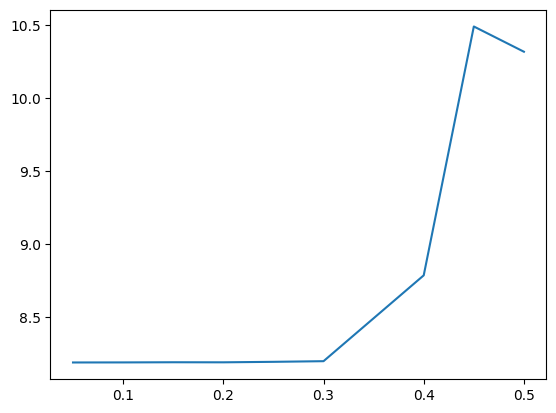

In [47]:
plt.plot([0.05,0.06,0.1,0.15,0.2,0.25,0.3,0.4,0.45,0.5],bestinvft)
#plt.yscale('log')
